# Notebook 04 — Machine Learning supervisado para estimación de valor de mercado

## Release v1.0.0 — Scouting Intelligence Platform

Este notebook extiende la modelización econométrica mediante modelos supervisados de Machine Learning aplicados al mismo problema analítico: estimar el valor de mercado esperado de futbolistas jóvenes en el mercado europeo.

En la release v1.0.0, el proyecto separa explícitamente:

```text
Historical Evaluation Layer
↓
Current Scouting Layer
↓
Player Intelligence Layer
↓
Decision Support Layer
```

Por tanto, este notebook pertenece principalmente a la **Historical Evaluation Layer**.

Su objetivo es evaluar si modelos supervisados no lineales mejoran el benchmark econométrico y generar una primera lectura de importancia de variables y ranking histórico.

La capa operativa final de la release v1.0.0 se apoya en el pipeline productivo:

```text
Tuned XGBoost
↓
Scoring Engine
↓
Risk Framework
↓
Current Scouting Layer
↓
Player Intelligence Layer
```

## Decisión metodológica Sprint 10

- Las temporadas **2019-2020 → 2023-2024** se utilizan como entrenamiento histórico.
- La temporada **2024-2025** se utiliza como test temporal out-of-sample.
- La temporada **2025-2026** se reserva para Current Scouting Layer y no debe entrar en la evaluación histórica del notebook.

Desde una perspectiva de TFM, este notebook responde a la pregunta:

> ¿Aportan los modelos supervisados de Machine Learning una mejora predictiva significativa respecto al modelo econométrico interpretable?


## 1. Configuración inicial

Se importan las librerías necesarias para manipulación de datos, modelización, evaluación y visualización. Se priorizan modelos de Machine Learning adecuados para datos tabulares y tamaños muestrales moderados.

Modelos incluidos:

- `RandomForestRegressor`: modelo de árboles en ensamblado, robusto ante no linealidades e interacciones.
- `GradientBoostingRegressor`: boosting secuencial, habitualmente competitivo en problemas tabulares.
- `HistGradientBoostingRegressor`: implementación eficiente de gradient boosting incluida en scikit-learn.

No se incluyen redes neuronales porque el tamaño de muestra es limitado y porque la interpretabilidad sigue siendo prioritaria en el proyecto.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "player_season_modeling.parquet"

OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_SEASONS = [
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

TEST_SEASON = "2024-2025"
CURRENT_SCOUTING_SEASON = "2025-2026"

TARGET = "log_market_value_eur"

print("Current working dir:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())


Current working dir: c:\Users\manue\Projects\market-value-football-tfm\notebooks
Project root: C:\Users\manue\Projects\market-value-football-tfm
Dataset path: C:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling.parquet
Dataset exists: True


## 2. Carga del dataset modelizable

Se utiliza el mismo dataset modelizable que en el modelo econométrico final. Esto garantiza comparabilidad metodológica entre OLS y Machine Learning.

No se reconstruye el pipeline de datos en este notebook: las fases de integración, matching, limpieza y filtrado ya han sido validadas previamente. Aquí se parte del dataset final de modelización para evitar inconsistencias entre notebooks.

In [2]:
df = pd.read_parquet(DATA_PATH)

print("Dataset cargado")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Players: {df['player_name_fbref'].nunique():,}" if 'player_name_fbref' in df.columns else "player_name_fbref no disponible")
print(f"Seasons: {df['season'].min()} - {df['season'].max()}")

available_cols = sorted(df.columns.tolist())
print("\nPrimeras columnas disponibles:")
print(available_cols[:40])

display(df.head())

Dataset cargado
Rows: 3,916
Columns: 54
Players: 2,136
Seasons: 2019-2020 - 2025-2026

Primeras columnas disponibles:
['age', 'age_diff', 'age_fbref', 'age_tm', 'assists', 'assists_per90', 'club', 'club_score', 'competition_id_tm', 'current_club_id_tm', 'current_club_name_tm', 'date_of_birth', 'delta_log_market_value_1y', 'foot', 'g_a', 'g_a_minus_pk_per90', 'g_a_per90', 'goals', 'goals_minus_pk', 'goals_minus_pk_per90', 'goals_per90', 'height_in_cm', 'league', 'log_market_value_eur', 'market_value_eur', 'market_value_growth_1y', 'market_value_next_eur', 'market_value_prev_eur', 'matches_played', 'matching_confidence', 'matching_method', 'matching_status', 'minutes_played', 'nationality', 'nineties', 'penalties_attempted', 'penalties_scored', 'player_id_tm', 'player_name_fbref', 'player_name_norm']


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age
0,Marvin Young,Sparta Rotterdam,Eredivisie,2025-2026,2025,DF,DEF,19.0000,33,33,2970,33.0000,0,1,1,0,0,0,7,0,0.0000,0.0300,0.0300,0.0000,0.0300,marvin young,"928,592.0000",Marvin Young,"2,025.0000",2025-10-02,"4,000,000.0000",15.2018,"2,500,000.0000","4,000,000.0000",0.0000,0.0000,20.0000,2005-10-02 00:00:00,Netherlands,Defender,Centre-Back,right,182.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.0000,100.0000,True,2025,20.0000
1,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2022-2023,2022,MF,MID,20.0000,34,29,2651,29.5000,4,2,6,4,0,0,2,0,0.1400,0.0700,0.2000,0.1400,0.2000,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,022.0000",2022-11-11,"1,200,000.0000",13.9978,"800,000.0000","3,000,000.0000",1.5000,0.9163,21.2731,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2731,100.0000,True,2022,21.2731
2,Teden Mengi,Luton Town,Premier League,2023-2024,2023,DF,DEF,21.0000,30,28,2469,27.4000,1,0,1,1,0,0,3,0,0.0400,0.0000,0.0400,0.0400,0.0400,teden mengi,"548,470.0000",Teden Mengi,"2,023.0000",2023-12-19,"7,000,000.0000",15.7614,"2,000,000.0000","12,000,000.0000",0.7143,0.5390,21.6372,2002-04-30 00:00:00,England,Defender,Centre-Back,right,186.0000,Luton Town,"1,031.0000",GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.6372,100.0000,True,2023,21.6372
3,Shurandy Sambo,Sparta Rotterdam,Eredivisie,2022-2023,2022,DF,DEF,20.0000,30,28,2307,25.6000,2,1,3,2,0,0,4,2,0.0800,0.0400,0.1200,0.0800,0.1200,shurandy sambo,"412,937.0000",Shurandy Sambo,"2,022.0000",2022-11-11,"700,000.0000",13.4588,"500,000.0000","3,000,000.0000",3.2857,1.4553,21.2293,2001-08-19 00:00:00,Curacao,Defender,Right-Back,right,174.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2293,100.0000,True,2022,21.2293
4,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2023-2024,2023,MF,MID,21.0000,24,24,2106,23.4000,5,2,7,3,2,2,2,0,0.2100,0.0900,0.3000,0.1300,0.2100,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,023.0000",2023-12-15,"4,500,000.0000",15.3196,"4,500,000.0000","4,500,000.0000",0.0000,0.0000,22.3655,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.3655,100.0000,True,2023,22.3655


## 3. Validaciones mínimas de calidad para modelización

Antes de entrenar modelos se comprueba que existen las columnas críticas:

- `log_market_value_eur`: target principal.
- `season_start_year` o `season`: necesarias para split temporal.
- `league`, `position_group`: efectos contextuales y categóricos.
- variables de rendimiento y exposición competitiva.

También se corrige de forma defensiva la variable `season_start_year` si no existe explícitamente.

In [3]:
df = df.copy()

if "season_start_year" not in df.columns:
    if "season" in df.columns:
        df["season_start_year"] = df["season"].astype(str).str[:4].astype(int)
    else:
        raise KeyError("No existe ni season_start_year ni season. No se puede hacer split temporal.")

required_cols = ["log_market_value_eur", "market_value_eur", "season_start_year"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Faltan columnas obligatorias: {missing_required}")

print("Validación básica completada")
print(df[["season", "season_start_year", "log_market_value_eur", "market_value_eur"]].head())

Validación básica completada
      season  season_start_year  log_market_value_eur  market_value_eur
0  2025-2026               2025               15.2018    4,000,000.0000
1  2022-2023               2022               13.9978    1,200,000.0000
2  2023-2024               2023               15.7614    7,000,000.0000
3  2022-2023               2022               13.4588      700,000.0000
4  2023-2024               2023               15.3196    4,500,000.0000


## 4. Definición del split temporal

La validación temporal reproduce un escenario realista de scouting: el modelo se entrena con temporadas pasadas y se evalúa sobre una temporada posterior no observada.

Configuración v1.0.0:

```text
Train histórico:
2019-2020 → 2023-2024

Test histórico:
2024-2025

Current Scouting Layer:
2025-2026
```

La temporada 2025-2026 queda excluida de la evaluación histórica del notebook. Su uso corresponde a la capa operativa de scouting actual.


In [4]:
train = df[df["season"].isin(TRAIN_SEASONS)].copy()
test = df[df["season"] == TEST_SEASON].copy()
current_scouting = df[df["season"] == CURRENT_SCOUTING_SEASON].copy()

print("Split temporal")
print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Current scouting rows: {len(current_scouting):,}")

print("\nTrain seasons:")
print(train["season"].value_counts().sort_index())
print("\nTest seasons:")
print(test["season"].value_counts().sort_index())
print("\nCurrent scouting season:")
print(current_scouting["season"].value_counts().sort_index())

if len(train) == 0 or len(test) == 0:
    raise ValueError("Train o test están vacíos. Revisar etiquetas de temporada.")


Split temporal
Train rows: 2,745
Test rows: 552
Current scouting rows: 619

Train seasons:
season
2019-2020    537
2020-2021    536
2021-2022    544
2022-2023    542
2023-2024    586
Name: count, dtype: int64

Test seasons:
season
2024-2025    552
Name: count, dtype: int64

Current scouting season:
season
2025-2026    619
Name: count, dtype: int64


## 5. Selección de variables para Machine Learning

La selección de features se divide en dos grupos:

1. **Features predictivas**, utilizadas para estimar valor de mercado.
2. **Variables de calidad**, reservadas para Confidence Score, análisis de robustez y scoring posterior.

Decisión metodológica v1.0.0:

Las variables de matching como `matching_confidence`, `age_diff`, `club_score` o `matching_method` no deben utilizarse como inputs predictivos principales porque no representan atributos futbolísticos ni de mercado del jugador. Su función correcta es modular la confianza del ranking, no explicar directamente el valor esperado.


In [5]:
# Variables numéricas candidatas predictivas.
numeric_candidates = [
    "age",
    "minutes_played",
    "log_minutes_played",
    "goals_per90",
    "assists_per90",
    "g_a_per90",
    "shots_per90",
    "progressive_passes_per90",
    "progressive_carries_per90",
    "tackles_per90",
    "interceptions_per90",
    "finishing_index",
    "playmaking_index",
    "progression_index",
    "defensive_index",
]

# Variables de calidad: NO se usan como inputs predictivos.
quality_features = [
    "matching_confidence",
    "age_diff",
    "club_score",
    "matching_method",
]

# Crear log_minutes_played si no existe.
for dataset in [train, test, current_scouting]:
    if "log_minutes_played" not in dataset.columns and "minutes_played" in dataset.columns:
        dataset["log_minutes_played"] = np.log1p(dataset["minutes_played"])

numeric_features = [c for c in numeric_candidates if c in train.columns]

categorical_candidates = [
    "league",
    "position_group",
]

categorical_features = [c for c in categorical_candidates if c in train.columns]

print("Numeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)
print("\nQuality features reserved for scoring/confidence:")
print([c for c in quality_features if c in train.columns])
print(f"\nTarget: {TARGET}")

if len(numeric_features) + len(categorical_features) == 0:
    raise ValueError("No hay features disponibles para entrenar modelos.")


Numeric features:
['age', 'minutes_played', 'log_minutes_played', 'goals_per90', 'assists_per90', 'g_a_per90']

Categorical features:
['league', 'position_group']

Quality features reserved for scoring/confidence:
['matching_confidence', 'age_diff', 'club_score', 'matching_method']

Target: log_market_value_eur


## 6. Preparación de matrices de modelización

Se separan variables explicativas (`X`) y target (`y`).

El preprocesamiento se encapsula dentro de un `Pipeline` para evitar leakage y garantizar que imputación, escalado y codificación categórica se ajustan únicamente con datos de entrenamiento.

Decisiones:

- Variables numéricas: imputación por mediana y escalado estándar.
- Variables categóricas: imputación por categoría más frecuente y one-hot encoding.

Aunque los modelos de árboles no necesitan escalado, se mantiene una transformación homogénea y controlada dentro del pipeline.

In [6]:
X_train = train[numeric_features + categorical_features].copy()
y_train = train[TARGET].copy()

X_test = test[numeric_features + categorical_features].copy()
y_test = test[TARGET].copy()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (2745, 8)
X_test: (552, 8)
y_train: (2745,)
y_test: (552,)


## 7. Funciones de evaluación

Se utilizan las mismas métricas que en el modelo econométrico:

- MAE logarítmico.
- RMSE logarítmico.
- R² out-of-sample.

Adicionalmente se calcula una traducción aproximada del error logarítmico a factor multiplicativo. Por ejemplo, un RMSE logarítmico de 0.70 implica que el error típico equivale aproximadamente a multiplicar/dividir el valor por `exp(0.70)`.

In [7]:
def regression_metrics(y_true, y_pred, label, split):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
    return {
        "model": label,
        "split": split,
        "MAE_log": mae,
        "RMSE_log": rmse,
        "R2": r2,
        "RMSE_multiplicative_factor": np.exp(rmse),
    }


def evaluate_model(name, fitted_model):
    pred_train = fitted_model.predict(X_train)
    pred_test = fitted_model.predict(X_test)
    return [
        regression_metrics(y_train, pred_train, name, "train"),
        regression_metrics(y_test, pred_test, name, "test"),
    ], pred_train, pred_test

## 8. Modelo benchmark: media histórica del target

Antes de entrenar modelos complejos, se calcula un baseline nulo que predice siempre la media de entrenamiento. Cualquier modelo útil debe superar claramente este benchmark.

In [8]:
mean_pred_train = np.full(shape=len(y_train), fill_value=y_train.mean())
mean_pred_test = np.full(shape=len(y_test), fill_value=y_train.mean())

results = []
results.append(regression_metrics(y_train, mean_pred_train, "M0_mean_train", "train"))
results.append(regression_metrics(y_test, mean_pred_test, "M0_mean_train", "test"))

pd.DataFrame(results)

,model,split,MAE_log,RMSE_log,R2,RMSE_multiplicative_factor
0,M0_mean_train,train,1.0960,1.3117,0.0000,3.7126
1,M0_mean_train,test,1.0899,1.3212,-0.0059,3.7478


## 9. Definición de modelos supervisados

Este notebook entrena modelos supervisados estándar de scikit-learn como comparación metodológica frente al benchmark econométrico.

La release v1.0.0 consolida posteriormente un pipeline productivo más avanzado con:

```text
Tuned Random Forest
Tuned LightGBM
HistGradientBoosting
Tuned XGBoost
```

El modelo productivo final documentado en el README es:

```text
Tuned XGBoost
R² = 0.5414
RMSE = 0.8892
MAE = 0.7120
```

Por tanto, este notebook debe interpretarse como una capa de validación y análisis histórico, no como el único pipeline ML productivo del repositorio.


In [9]:
models = {
    "ML1_RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "ML2_GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_samples_leaf=10,
        subsample=0.85,
        random_state=RANDOM_STATE,
    ),
    "ML3_HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=31,
        min_samples_leaf=15,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
    ),
}

pipelines = {
    name: Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    for name, model in models.items()
}

pipelines

{'ML1_RandomForest': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['age', 'minutes_played',
                                                    'log_minutes_played',
                                                    'goals_per90',
                                                    'assists_per90',
                                                    'g_a_per90']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                

## 10. Entrenamiento y evaluación out-of-sample

Se entrenan los modelos únicamente con el conjunto histórico y se evalúan en la temporada 2024-2025. Esta evaluación representa el criterio principal para comparar modelos, ya que simula el uso real del sistema para detectar oportunidades futuras.

In [10]:
fitted_models = {}
predictions = {
    "M0_mean_train": {
        "train": mean_pred_train,
        "test": mean_pred_test,
    }
}

for name, pipe in pipelines.items():
    print(f"Training {name}...")
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    model_results, pred_train, pred_test = evaluate_model(name, pipe)
    results.extend(model_results)
    predictions[name] = {"train": pred_train, "test": pred_test}

metrics_df = pd.DataFrame(results).sort_values(["split", "RMSE_log"])
metrics_df.to_csv(OUTPUT_DIR / "04_ml_model_metrics.csv", index=False)

display(metrics_df)

Training ML1_RandomForest...
Training ML2_GradientBoosting...
Training ML3_HistGradientBoosting...


,model,split,MAE_log,RMSE_log,R2,RMSE_multiplicative_factor
5,ML2_GradientBoosting,test,0.7866,0.9867,0.4390,2.6823
3,ML1_RandomForest,test,0.7894,0.9953,0.4291,2.7056
7,ML3_HistGradientBoosting,test,0.8105,1.0279,0.3911,2.7953
1,M0_mean_train,test,1.0899,1.3212,-0.0059,3.7478
6,ML3_HistGradientBoosting,train,0.5852,0.7318,0.6887,2.0789
2,ML1_RandomForest,train,0.7308,0.9070,0.5219,2.4769
4,ML2_GradientBoosting,train,0.7511,0.9265,0.5011,2.5257
0,M0_mean_train,train,1.0960,1.3117,0.0000,3.7126


## 11. Comparación contra el modelo econométrico final

Si existe el archivo de métricas del Notebook 03, se incorpora para comparar directamente OLS vs Machine Learning.

Esta comparación es clave para la memoria: el modelo econométrico ofrece interpretabilidad causal/asociativa y explicación económica; los modelos ML pueden aportar mejora predictiva, pero su valor debe justificarse empíricamente.

In [11]:
ols_metrics_path_candidates = [
    OUTPUT_DIR / "03_econometric_model_metrics.csv",
    OUTPUT_DIR / "03_econometric_model_metrics.csv",
    OUTPUT_DIR / "02_baseline_model_metrics.csv",
]

ols_metrics = None
for path in ols_metrics_path_candidates:
    if path.exists():
        ols_metrics = pd.read_csv(path)
        print(f"Métricas econométricas cargadas desde: {path}")
        break

if ols_metrics is not None:
    # Normalizar nombres si hiciera falta.
    common_cols = [c for c in ["model", "split", "MAE_log", "RMSE_log", "R2"] if c in ols_metrics.columns]
    ols_compare = ols_metrics[common_cols].copy()
    ml_compare = metrics_df[["model", "split", "MAE_log", "RMSE_log", "R2"]].copy()
    comparison_df = pd.concat([ols_compare, ml_compare], ignore_index=True)
else:
    print("No se encontró archivo de métricas del Notebook 03. Se muestra solo ML.")
    comparison_df = metrics_df[["model", "split", "MAE_log", "RMSE_log", "R2"]].copy()

comparison_test = comparison_df[comparison_df["split"] == "test"].sort_values("RMSE_log")
comparison_test.to_csv(OUTPUT_DIR / "04_model_comparison_test.csv", index=False)

display(comparison_test)

Métricas econométricas cargadas desde: C:\Users\manue\Projects\market-value-football-tfm\data\outputs\03_econometric_model_metrics.csv


,model,split,MAE_log,RMSE_log,R2
8,ML2_GradientBoosting,test,0.7866,0.9867,0.4390
0,M2_base_FE,test,0.7947,0.9887,0.4366
1,M3_final_FE_advanced,test,0.7947,0.9887,0.4366
9,ML1_RandomForest,test,0.7894,0.9953,0.4291
10,ML3_HistGradientBoosting,test,0.8105,1.0279,0.3911
2,M1_base_no_FE,test,1.0036,1.2165,0.1472
3,M0_mean_train,test,1.0899,1.3212,-0.0059
11,M0_mean_train,test,1.0899,1.3212,-0.0059


## 12. Visualización de rendimiento out-of-sample

Se visualizan las métricas principales en test. La interpretación debe centrarse en la comparación relativa:

- Si ML mejora solo marginalmente a OLS, el modelo econométrico puede seguir siendo la opción principal por interpretabilidad.
- Si ML mejora claramente a OLS, puede usarse como motor predictivo complementario para scoring.

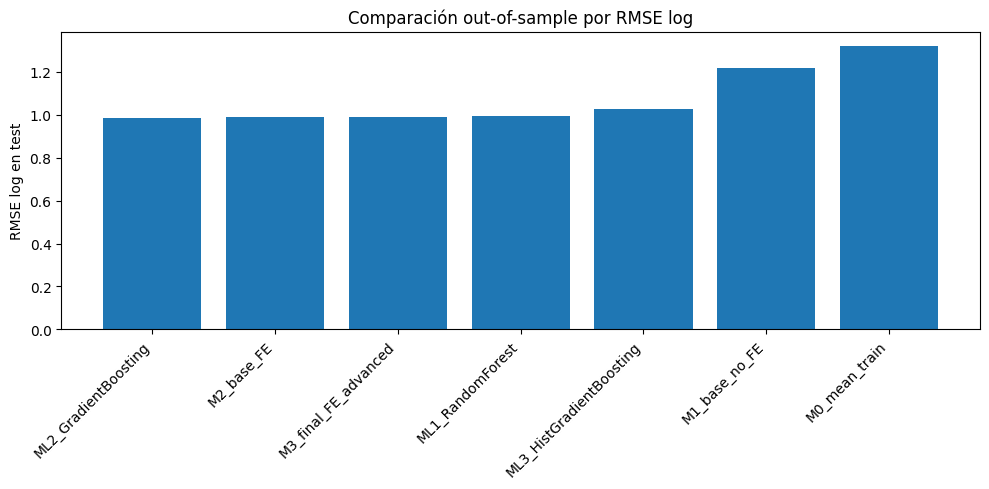

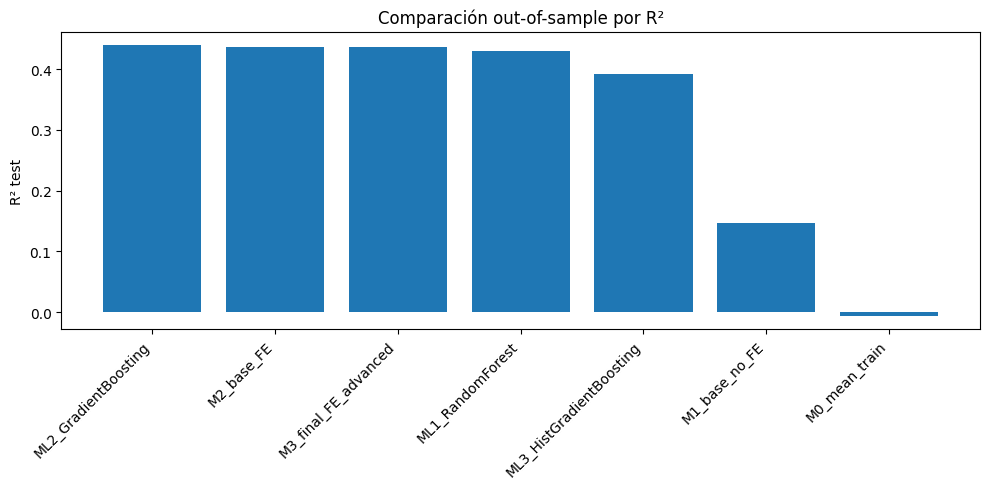

In [12]:
plot_df = comparison_test.copy()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["RMSE_log"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE log en test")
plt.title("Comparación out-of-sample por RMSE log")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² test")
plt.title("Comparación out-of-sample por R²")
plt.tight_layout()
plt.show()

## 13. Selección del mejor modelo ML del notebook

La selección se realiza por menor RMSE sobre el test histórico 2024-2025.

Importante:

El mejor modelo de este notebook no necesariamente coincide con el modelo productivo final de la release v1.0.0, ya que el pipeline productivo tuned se ejecuta desde scripts modulares con búsqueda de hiperparámetros y persistencia de artefactos.


In [13]:
ml_test_metrics = metrics_df[(metrics_df["split"] == "test") & (metrics_df["model"] != "M0_mean_train")].copy()
best_ml_name = ml_test_metrics.sort_values("RMSE_log").iloc[0]["model"]
best_ml_model = fitted_models[best_ml_name]

print(f"Best ML model by test RMSE: {best_ml_name}")
display(ml_test_metrics.sort_values("RMSE_log"))

Best ML model by test RMSE: ML2_GradientBoosting


,model,split,MAE_log,RMSE_log,R2,RMSE_multiplicative_factor
5,ML2_GradientBoosting,test,0.7866,0.9867,0.4390,2.6823
3,ML1_RandomForest,test,0.7894,0.9953,0.4291,2.7056
7,ML3_HistGradientBoosting,test,0.8105,1.0279,0.3911,2.7953


## 14. Predicciones del mejor modelo y transformación a euros

Las predicciones se transforman desde escala logarítmica a euros para facilitar interpretación de negocio.

Estas predicciones se utilizan para construir un ranking histórico exploratorio sobre la temporada 2024-2025.

La capa operativa actual 2025-2026 se genera posteriormente mediante el pipeline productivo Tuned XGBoost.


In [14]:
test_scored = test.copy()
test_scored["predicted_log_market_value_ml"] = predictions[best_ml_name]["test"]
test_scored["predicted_market_value_ml_eur"] = np.exp(test_scored["predicted_log_market_value_ml"])

test_scored["inefficiency_score_ml"] = (
    test_scored["predicted_log_market_value_ml"] - test_scored["log_market_value_eur"]
)

test_scored["market_value_gap_ml_eur"] = (
    test_scored["predicted_market_value_ml_eur"] - test_scored["market_value_eur"]
)

test_scored["market_value_gap_ml_pct"] = (
    test_scored["predicted_market_value_ml_eur"] / test_scored["market_value_eur"] - 1
)

# Z-score del score dentro del test.
score_std = test_scored["inefficiency_score_ml"].std(ddof=0)
if pd.isna(score_std) or score_std == 0:
    test_scored["inefficiency_score_ml_z"] = 0.0
else:
    test_scored["inefficiency_score_ml_z"] = (
        test_scored["inefficiency_score_ml"] - test_scored["inefficiency_score_ml"].mean()
    ) / score_std

print("Predicciones y scores generados")
display(test_scored[["market_value_eur", "predicted_market_value_ml_eur", "inefficiency_score_ml", "market_value_gap_ml_eur", "market_value_gap_ml_pct"]].head())

Predicciones y scores generados


,market_value_eur,predicted_market_value_ml_eur,inefficiency_score_ml,market_value_gap_ml_eur,market_value_gap_ml_pct
5,"1,500,000.0000","4,792,545.7962",1.1616,"3,292,545.7962",2.1950
6,"1,300,000.0000","1,501,280.7971",0.1440,"201,280.7971",0.1548
11,"500,000.0000","9,689,610.7723",2.9642,"9,189,610.7723",18.3792
13,"650,000.0000","1,365,955.3138",0.7426,"715,955.3138",1.1015
21,"1,000,000.0000","1,550,607.2135",0.4386,"550,607.2135",0.5506


## 15. Construcción del Opportunity Score ML exploratorio

Este Opportunity Score tiene carácter exploratorio dentro del notebook.

En la arquitectura v1.0.0, el scoring operativo final se construye en módulos específicos y añade:

- Growth Score;
- Confidence Score;
- Risk Score;
- Risk-adjusted Opportunity Score;
- Opportunity vs Risk Matrix.

Por tanto, el score calculado aquí sirve como antecedente metodológico, no como scoring final de producción.


In [15]:
# Confidence score defensivo y trazable.
test_scored["confidence_score_ml"] = 1.0

if "matching_confidence" in test_scored.columns:
    test_scored["confidence_score_ml"] *= test_scored["matching_confidence"].fillna(0.85).clip(0, 1)

if "minutes_played" in test_scored.columns:
    minutes_factor = (test_scored["minutes_played"] / 900).clip(0.5, 1.0)
    test_scored["confidence_score_ml"] *= minutes_factor

if "age_diff" in test_scored.columns:
    age_penalty = (1 - (test_scored["age_diff"].fillna(0) / 1.5) * 0.15).clip(0.75, 1.0)
    test_scored["confidence_score_ml"] *= age_penalty

# Opportunity score: solo premia infravaloración positiva.
test_scored["opportunity_score_ml"] = (
    test_scored["inefficiency_score_ml_z"].clip(lower=0) * test_scored["confidence_score_ml"]
)

display(test_scored[["inefficiency_score_ml", "inefficiency_score_ml_z", "confidence_score_ml", "opportunity_score_ml"]].describe())

,inefficiency_score_ml,inefficiency_score_ml_z,confidence_score_ml,opportunity_score_ml
count,552.0000,552.0000,552.0000,552.0000
mean,-0.1068,-0.0000,0.7168,0.2784
std,0.9818,1.0009,0.1534,0.4192
min,-3.0472,-2.9978,0.3666,0.0000
25%,-0.8093,-0.7162,0.6900,0.0000
50%,-0.0819,0.0254,0.7734,0.0163
75%,0.5344,0.6537,0.8026,0.4680
max,2.9642,3.1309,0.9982,2.8433


## 16. Ranking ML de jugadores potencialmente infravalorados

Se genera un ranking con los jugadores cuyo valor estimado por el modelo ML supera su valor observado de mercado.

Interpretación:

- `inefficiency_score_ml > 0`: posible infravaloración.
- `market_value_gap_ml_eur > 0`: gap absoluto positivo en euros.
- `opportunity_score_ml`: priorización ajustada por confianza.

Este ranking debe considerarse una shortlist cuantitativa para scouting, no una recomendación automática de fichaje.

In [16]:
name_candidates = ["player_name_fbref", "player_name", "player_name_tm"]
name_col = next((c for c in name_candidates if c in test_scored.columns), None)

ranking_cols = [c for c in [
    name_col,
    "player_id_tm",
    "club",
    "current_club_name_tm",
    "league",
    "season",
    "position_group",
    "age",
    "minutes_played",
    "market_value_eur",
    "predicted_market_value_ml_eur",
    "market_value_gap_ml_eur",
    "market_value_gap_ml_pct",
    "log_market_value_eur",
    "predicted_log_market_value_ml",
    "inefficiency_score_ml",
    "inefficiency_score_ml_z",
    "confidence_score_ml",
    "opportunity_score_ml",
    "matching_method",
    "matching_confidence",
    "age_diff",
    "club_score",
] if c is not None and c in test_scored.columns]

undervalued_ml_ranking = (
    test_scored
    .query("inefficiency_score_ml > 0")
    .sort_values(["opportunity_score_ml", "market_value_gap_ml_eur"], ascending=False)
    [ranking_cols]
    .head(50)
    .copy()
)

overvalued_ml_ranking = (
    test_scored
    .query("inefficiency_score_ml < 0")
    .sort_values(["inefficiency_score_ml", "market_value_gap_ml_eur"], ascending=True)
    [ranking_cols]
    .head(50)
    .copy()
)

undervalued_ml_ranking.to_csv(OUTPUT_DIR / "04_ml_undervalued_ranking.csv", index=False)
overvalued_ml_ranking.to_csv(OUTPUT_DIR / "04_ml_overvalued_ranking.csv", index=False)

display(undervalued_ml_ranking.head(20))

,player_name_fbref,player_id_tm,club,current_club_name_tm,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_ml_eur,market_value_gap_ml_eur,market_value_gap_ml_pct,log_market_value_eur,predicted_log_market_value_ml,inefficiency_score_ml,inefficiency_score_ml_z,confidence_score_ml,opportunity_score_ml,matching_method,matching_confidence,age_diff,club_score
11,Lasse Rosenboom,"512,352.0000",Holstein Kiel,Holstein Kiel,Bundesliga,2024-2025,MID,22.9185,1734,"500,000.0000","9,689,610.7723","9,189,610.7723",18.3792,13.1224,16.0866,2.9642,3.1309,0.9081,2.8433,exact_age_club_validated,1.0000,0.9185,100.0000
2804,Mario Martín,"948,273.0000",Valladolid,Getafe Club de Fútbol S. A. D. Team Dubai,LaLiga,2024-2025,MID,20.6023,1748,"500,000.0000","7,893,937.7852","7,393,937.7852",14.7879,13.1224,15.8816,2.7592,2.9220,0.7988,2.3341,exact_age_validated,0.8500,0.6023,20.8333
1588,Yassin Belkhdim,"807,688.0000",Angers,Angers Sporting Club de l'Ouest,Ligue 1,2024-2025,MID,22.6448,1523,"500,000.0000","5,943,089.5480","5,443,089.5480",10.8862,13.1224,15.5977,2.4754,2.6326,0.7952,2.0934,exact_age_validated,0.8500,0.6448,32.4324
3033,Jesus Rodríguez,"1,190,411.0000",Real Betis,Calcio Como,LaLiga,2024-2025,MID,18.8966,1111,"700,000.0000","8,570,096.8261","7,870,096.8261",11.2430,13.4588,15.9638,2.5050,2.6627,0.7738,2.0604,exact_age_validated,0.8500,0.8966,19.0476
1013,Pau Navarro,"1,061,336.0000",Villarreal,Villarreal Club de Fútbol S.A.D.,LaLiga,2024-2025,DEF,19.6496,916,"500,000.0000","4,145,954.5099","3,645,954.5099",7.2919,13.1224,15.2376,2.1153,2.2655,0.7948,1.8006,exact_age_validated,0.8500,0.6496,48.7805
1649,Kévin Danois,"743,496.0000",Auxerre,Association de la Jeunesse auxerroise,Ligue 1,2024-2025,MID,20.2765,1460,"500,000.0000","3,469,123.5171","2,969,123.5171",5.9382,13.1224,15.0594,1.9370,2.0837,0.8265,1.7222,exact_age_validated,0.8500,0.2765,31.8182
1760,Jérémy Jacquet,"1,004,301.0000",Rennes,Stade Rennais Football Club,Ligue 1,2024-2025,DEF,19.2252,927,"600,000.0000","3,492,213.0373","2,892,213.0373",4.8204,13.3047,15.0660,1.7614,1.9046,0.8309,1.5825,exact_age_validated,0.8500,0.2252,30.3030
645,Antoine Hainaut,"917,375.0000",Parma,Parma Calcio 1913,Serie A,2024-2025,DEF,22.6639,1206,"750,000.0000","4,711,675.3292","3,961,675.3292",5.2822,13.5278,15.3656,1.8377,1.9825,0.7936,1.5732,exact_age_validated,0.8500,0.6639,58.8235
1642,Clément Akpa,"806,793.0000",Auxerre,Association de la Jeunesse auxerroise,Ligue 1,2024-2025,DEF,22.8693,2486,"1,000,000.0000","6,418,389.5100","5,418,389.5100",5.4184,13.8155,15.6747,1.8592,2.0043,0.7761,1.5556,exact_age_validated,0.8500,0.8693,31.8182
1651,Louis Mouton,"904,662.0000",Saint-Étienne,Angers Sporting Club de l'Ouest,Ligue 1,2024-2025,MID,22.5216,1045,"800,000.0000","4,730,787.9404","3,930,787.9404",4.9135,13.5924,15.3696,1.7772,1.9208,0.8057,1.5475,exact_age_validated,0.8500,0.5216,31.8182


## 17. Análisis agregado del Inefficiency Score ML por liga

Este análisis permite identificar si el modelo ML concentra oportunidades en determinadas ligas. Es especialmente relevante para el proyecto porque Eredivisie y Liga Portugal son mercados estratégicos para detectar talento joven potencialmente infravalorado.

Debe interpretarse con cautela: un score medio elevado por liga puede reflejar oportunidades reales, pero también sesgos del modelo o diferencias estructurales no capturadas.

In [17]:
league_score_ml = (
    test_scored
    .groupby("league", dropna=False)
    .agg(
        n=("inefficiency_score_ml", "size"),
        mean_inefficiency_ml=("inefficiency_score_ml", "mean"),
        median_inefficiency_ml=("inefficiency_score_ml", "median"),
        mean_gap_ml_eur=("market_value_gap_ml_eur", "mean"),
        median_gap_ml_eur=("market_value_gap_ml_eur", "median"),
        mean_gap_ml_pct=("market_value_gap_ml_pct", "mean"),
        mean_confidence_ml=("confidence_score_ml", "mean"),
        mean_opportunity_ml=("opportunity_score_ml", "mean"),
    )
    .reset_index()
    .sort_values("mean_inefficiency_ml", ascending=False)
)

league_score_ml.to_csv(OUTPUT_DIR / "04_ml_inefficiency_by_league.csv", index=False)
display(league_score_ml)

,league,n,mean_inefficiency_ml,median_inefficiency_ml,mean_gap_ml_eur,median_gap_ml_eur,mean_gap_ml_pct,mean_confidence_ml,mean_opportunity_ml
2,LaLiga,72,0.1302,0.2748,"-7,153,655.1163","1,119,578.7796",1.1098,0.7361,0.4462
3,Liga Portugal,60,-0.0413,0.1044,"-2,564,034.8450","179,612.1235",0.4450,0.6753,0.3110
6,Serie A,77,-0.0481,-0.1355,"-2,320,564.2562","-619,630.6245",0.3670,0.6842,0.2382
4,Ligue 1,99,-0.0983,-0.1179,"-4,325,017.8576","-667,483.9407",0.5340,0.7174,0.2916
1,Eredivisie,93,-0.1291,0.0172,"-2,196,549.7549","20,792.9859",0.3554,0.7464,0.3001
0,Bundesliga,77,-0.1578,-0.2197,"-7,256,920.6353","-1,787,299.4776",0.4911,0.7204,0.2444
5,Premier League,74,-0.3820,-0.4640,"-9,520,937.5429","-9,867,568.6492",-0.0091,0.7240,0.1211


## 18. Análisis agregado del Inefficiency Score ML por posición

El mercado no valora igual las posiciones. Los atacantes suelen tener primas de mercado superiores por goles y visibilidad, mientras que defensas, centrocampistas y porteros pueden presentar patrones distintos.

Este análisis ayuda a evaluar si el modelo está sesgado hacia determinados perfiles o si identifica oportunidades en posiciones menos visibles.

In [18]:
position_score_ml = (
    test_scored
    .groupby("position_group", dropna=False)
    .agg(
        n=("inefficiency_score_ml", "size"),
        mean_inefficiency_ml=("inefficiency_score_ml", "mean"),
        median_inefficiency_ml=("inefficiency_score_ml", "median"),
        mean_gap_ml_eur=("market_value_gap_ml_eur", "mean"),
        median_gap_ml_eur=("market_value_gap_ml_eur", "median"),
        mean_gap_ml_pct=("market_value_gap_ml_pct", "mean"),
        mean_confidence_ml=("confidence_score_ml", "mean"),
        mean_opportunity_ml=("opportunity_score_ml", "mean"),
    )
    .reset_index()
    .sort_values("mean_inefficiency_ml", ascending=False)
)

position_score_ml.to_csv(OUTPUT_DIR / "04_ml_inefficiency_by_position.csv", index=False)
display(position_score_ml)

,position_group,n,mean_inefficiency_ml,median_inefficiency_ml,mean_gap_ml_eur,median_gap_ml_eur,mean_gap_ml_pct,mean_confidence_ml,mean_opportunity_ml
0,ATT,50,-0.0525,0.1746,"-3,097,200.4696","784,563.1530",0.3802,0.6707,0.2952
2,GK,16,-0.0653,0.0047,"-1,482,468.1983","-3,679.8104",0.0845,0.7126,0.1861
3,MID,285,-0.0748,-0.0906,"-5,344,916.9501","-667,483.9407",0.5415,0.7233,0.2832
1,DEF,201,-0.1691,-0.1141,"-5,181,572.2566","-450,763.2900",0.4141,0.7195,0.2748


## 19. Observado vs predicho

El gráfico observado vs predicho permite evaluar visualmente la calibración del modelo. Un modelo perfectamente calibrado situaría los puntos sobre la diagonal.

En modelos de valor de mercado suele observarse mayor error en jugadores de valor extremo, ya que el mercado incorpora factores no observados como duración contractual, reputación, internacionalidad, agencia, lesiones o presión mediática.

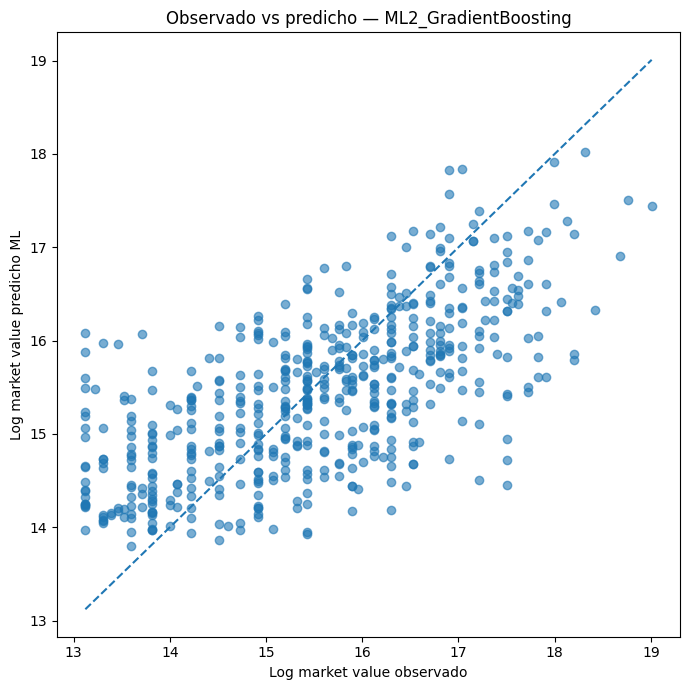

In [19]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_scored["predicted_log_market_value_ml"], alpha=0.6)
min_val = min(y_test.min(), test_scored["predicted_log_market_value_ml"].min())
max_val = max(y_test.max(), test_scored["predicted_log_market_value_ml"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Log market value observado")
plt.ylabel("Log market value predicho ML")
plt.title(f"Observado vs predicho — {best_ml_name}")
plt.tight_layout()
plt.show()

## 20. Distribución de residuos ML

Los residuos permiten analizar sesgos del modelo:

- Residuo positivo: el modelo estima más valor que el mercado observado; posible infravaloración.
- Residuo negativo: el mercado observado supera la estimación; posible sobrevaloración.

La forma de la distribución ayuda a detectar asimetrías y outliers.

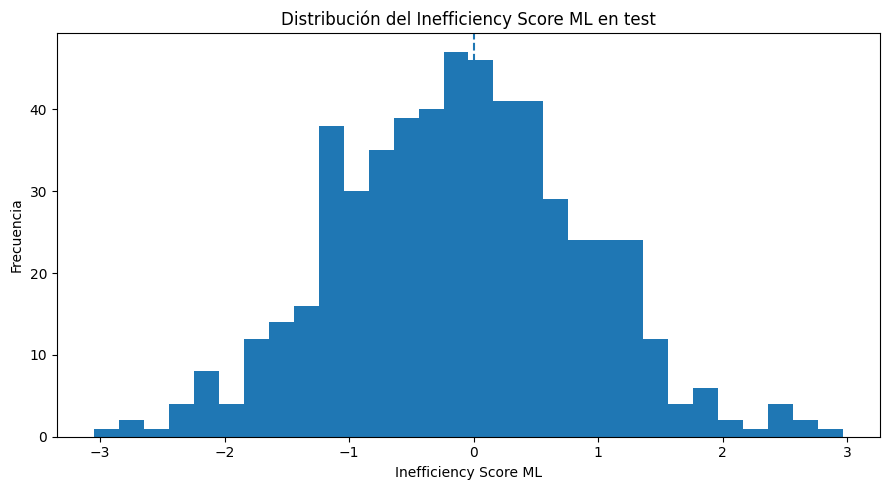

count   552.0000
mean     -0.1068
std       0.9818
min      -3.0472
25%      -0.8093
50%      -0.0819
75%       0.5344
max       2.9642
Name: inefficiency_score_ml, dtype: float64

In [20]:
plt.figure(figsize=(9, 5))
plt.hist(test_scored["inefficiency_score_ml"], bins=30)
plt.axvline(0, linestyle="--")
plt.xlabel("Inefficiency Score ML")
plt.ylabel("Frecuencia")
plt.title("Distribución del Inefficiency Score ML en test")
plt.tight_layout()
plt.show()

display(test_scored["inefficiency_score_ml"].describe())

## 21. Importancia de variables por permutation importance

Para mantener interpretabilidad, se calcula `permutation importance` sobre el conjunto de test.

Esta técnica mide cuánto empeora el rendimiento del modelo al permutar aleatoriamente cada variable. Si permutar una variable empeora mucho el modelo, esa variable es importante para la predicción.

Limitación: en presencia de variables correlacionadas, la importancia puede repartirse entre ellas.

,feature,importance_mean,importance_std
6,league,0.3784,0.0268
2,log_minutes_played,0.0587,0.0059
5,g_a_per90,0.0543,0.0134
1,minutes_played,0.0264,0.0038
4,assists_per90,0.0155,0.0049
0,age,0.0092,0.0041
3,goals_per90,0.0009,0.0028
7,position_group,0.0003,0.0008


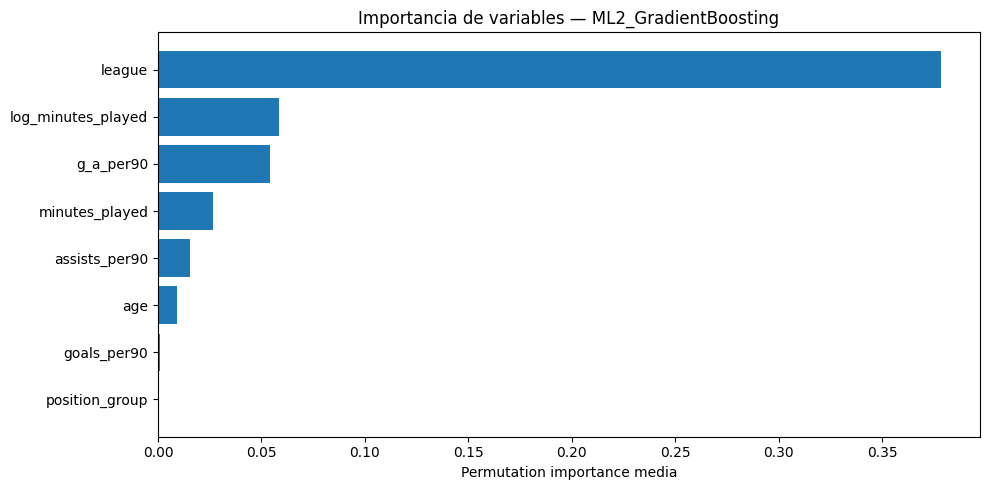

In [21]:
perm = permutation_importance(
    best_ml_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv(OUTPUT_DIR / "04_ml_permutation_importance.csv", index=False)

display(importance_df)

plt.figure(figsize=(10, 5))
plot_imp = importance_df.head(15).sort_values("importance_mean")
plt.barh(plot_imp["feature"], plot_imp["importance_mean"])
plt.xlabel("Permutation importance media")
plt.title(f"Importancia de variables — {best_ml_name}")
plt.tight_layout()
plt.show()

## 22. Estabilidad del ranking: comparación OLS vs ML

Un buen sistema de scouting no solo debe tener buen RMSE, sino generar rankings razonablemente estables. Si el ranking cambia completamente al cambiar de modelo, la señal de infravaloración es menos fiable.

Si existe el ranking del Notebook 03, se compara el solapamiento entre los principales jugadores infravalorados por OLS y por ML.

In [22]:
ols_ranking_path = OUTPUT_DIR / "03_undervalued_ranking.csv"

if ols_ranking_path.exists():
    ols_rank = pd.read_csv(ols_ranking_path)
    ml_rank = undervalued_ml_ranking.copy()

    # Elegir una clave de comparación robusta.
    possible_keys = ["player_id_tm", "player_name_fbref", "player_name", "player_name_tm"]
    key = next((c for c in possible_keys if c in ols_rank.columns and c in ml_rank.columns), None)

    if key is not None:
        stability_rows = []
        for k in [10, 20, 30, 50]:
            ols_set = set(ols_rank.head(k)[key].dropna().astype(str))
            ml_set = set(ml_rank.head(k)[key].dropna().astype(str))
            overlap = len(ols_set & ml_set)
            stability_rows.append({
                "top_k": k,
                "overlap": overlap,
                "overlap_rate": overlap / k if k else np.nan,
            })
        stability_df = pd.DataFrame(stability_rows)
        stability_df.to_csv(OUTPUT_DIR / "04_ranking_stability_ols_vs_ml.csv", index=False)
        print(f"Clave usada para comparar rankings: {key}")
        display(stability_df)
    else:
        print("No se encontró una clave común fiable para comparar rankings OLS vs ML.")
else:
    print("No existe 03_undervalued_ranking.csv. Se omite comparación OLS vs ML.")

Clave usada para comparar rankings: player_id_tm


,top_k,overlap,overlap_rate
0,10,7,0.7000
1,20,14,0.7000
2,30,20,0.6667
3,50,34,0.6800


## 23. Exportación de predicciones completas

Se exportan las predicciones del mejor modelo ML y los rankings principales para uso posterior en:

- memoria del TFM;
- análisis de scouting;
- dashboard;
- comparación con modelo econométrico;
- construcción del ranking final integrado.

In [23]:
scored_output_cols = [c for c in [
    name_col,
    "player_id_tm",
    "club",
    "current_club_name_tm",
    "league",
    "season",
    "position_group",
    "age",
    "minutes_played",
    "market_value_eur",
    "log_market_value_eur",
    "predicted_log_market_value_ml",
    "predicted_market_value_ml_eur",
    "inefficiency_score_ml",
    "inefficiency_score_ml_z",
    "market_value_gap_ml_eur",
    "market_value_gap_ml_pct",
    "confidence_score_ml",
    "opportunity_score_ml",
    "matching_method",
    "matching_confidence",
    "age_diff",
    "club_score",
] if c is not None and c in test_scored.columns]

test_scored[scored_output_cols].to_parquet(OUTPUT_DIR / "04_ml_test_predictions.parquet", index=False)
test_scored[scored_output_cols].to_csv(OUTPUT_DIR / "04_ml_test_predictions.csv", index=False)

print("Outputs exploratorios exportados desde Notebook 04:")
print("- 04_ml_model_metrics.csv")
print("- 04_model_comparison_test.csv")
print("- 04_ml_test_predictions.parquet")
print("- 04_ml_test_predictions.csv")
print("- 04_ml_undervalued_ranking.csv")
print("- 04_ml_overvalued_ranking.csv")
print("- 04_ml_inefficiency_by_league.csv")
print("- 04_ml_inefficiency_by_position.csv")
print("- 04_ml_permutation_importance.csv")

Outputs exploratorios exportados desde Notebook 04:
- 04_ml_model_metrics.csv
- 04_model_comparison_test.csv
- 04_ml_test_predictions.parquet
- 04_ml_test_predictions.csv
- 04_ml_undervalued_ranking.csv
- 04_ml_overvalued_ranking.csv
- 04_ml_inefficiency_by_league.csv
- 04_ml_inefficiency_by_position.csv
- 04_ml_permutation_importance.csv


## 23.1 Relación con Current Scouting Layer

La temporada 2025-2026 queda reservada para scoring operativo actual.

Este notebook no genera la shortlist final de scouting. La shortlist productiva se genera mediante:

```text
artifacts/predictions/tuned_xgboost_predictions.csv
↓
reports/rankings/scouting_shortlist.csv
↓
reports/rankings/scouting_shortlist_with_risk.csv
```

Esa capa incorpora Risk Score y alimenta el dashboard de Player Intelligence.

La separación evita que la temporada actual contamine la validación histórica y mantiene trazabilidad metodológica entre evaluación y operación.


## 24. Conclusiones del Notebook 04

El Notebook 04 demuestra que los modelos supervisados de Machine Learning aportan valor como extensión predictiva del benchmark econométrico.

La principal corrección metodológica de la release v1.0.0 es que el notebook se integra dentro de la **Historical Evaluation Layer** y no debe confundirse con la capa operativa de scouting actual.

Configuración temporal:

- Train: 2019-2020 → 2023-2024.
- Test: 2024-2025.
- Current Scouting: 2025-2026, excluida de la evaluación histórica.

Conclusiones principales:

1. Machine Learning mejora la capacidad predictiva respecto a modelos lineales simples y al benchmark econométrico en varias configuraciones.
2. La mejora es real, aunque moderada, lo que indica que el cuello de botella principal no es solo algorítmico sino de riqueza del feature set.
3. Las variables de contexto competitivo, producción ofensiva y volumen de juego siguen concentrando una parte relevante de la señal predictiva.
4. Las variables de matching deben utilizarse como señales de calidad y confianza, no como atributos predictivos principales.
5. El ranking generado en este notebook tiene valor exploratorio y metodológico, pero no constituye la shortlist operativa final.
6. La release v1.0.0 utiliza Tuned XGBoost como modelo productivo final dentro de una arquitectura de Scouting Intelligence.

Resultados finales documentados para la release:

| Modelo | MAE | RMSE | R² |
|----------|----------:|----------:|----------:|
| Growth OLS | 0.7287 | 0.9053 | 0.5258 |
| Tuned XGBoost | 0.7120 | 0.8892 | 0.5414 |

La mejora de Tuned XGBoost sobre Growth OLS es moderada:

```text
ΔR² ≈ +0.0156
```

Este resultado refuerza una conclusión metodológica central del TFM:

```text
El valor del sistema no reside únicamente en mejorar R²,
sino en transformar predicciones en recomendaciones interpretables,
priorizadas y ajustadas por riesgo.
```

En la arquitectura final, este notebook cumple la función de puente entre:

```text
Econometric Benchmark
↓
Machine Learning
↓
Scoring Engine
↓
Current Scouting Layer
↓
Player Intelligence Layer
```

La evolución posterior del sistema dependerá principalmente de la incorporación de métricas avanzadas de rendimiento, especialmente las identificadas durante Sprint 10.2 en la auditoría de FBref.
